# Análisis de temperaturas de Open Meteo

## Conexión y librerías

In [1]:
import io
import subprocess
import pandas as pd
import matplotlib.pyplot as plt

preferred_style = 'seaborn-v0_8' if 'seaborn-v0_8' in plt.style.available else 'default'
plt.style.use(preferred_style)
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.grid'] = True

## Lectura de datos desde MySQL

Esta celda usa Docker Compose para ejecutar una consulta dentro del contenedor MySQL y traer el resultado como CSV.

In [11]:
query = """
SELECT
    id,
    endpoint,
    city,
    requested_latitude,
    requested_longitude,
    latitude,
    longitude,
    temperature,
    unit,
    read_at,
    timezone,
    source,
    api_instance,
    provider_timestamp,
    created_at
FROM openmeteo.temperature_readings
ORDER BY city, read_at;
"""

cmd = [
    'docker', 'compose', 'exec', '-T',
    'mysql',
    'mysql', '-uroot', '-proot',
    '--batch', '--raw',
    '-e', query
]

result = subprocess.run(cmd, capture_output=True, text=True)

if result.returncode != 0:
    raise RuntimeError(result.stderr)

raw_text = result.stdout.strip()

if not raw_text:
    raise ValueError('No hay datos en temperature_readings todavía.')

df = pd.read_csv(io.StringIO(raw_text), sep='\t', header=0)

df.columns = [
    "id","endpoint","city","requested_latitude","requested_longitude",
    "latitude","longitude","temperature","unit","read_at","timezone",
    "source","api_instance","provider_timestamp","created_at"
]

df['temperature'] = pd.to_numeric(df['temperature'], errors='coerce')

df['read_at'] = pd.to_datetime(df['read_at'], format='%Y-%m-%d %H:%M:%S', errors='coerce')
df['provider_timestamp'] = pd.to_datetime(df['provider_timestamp'], format='%Y-%m-%d %H:%M:%S', errors='coerce')
df['created_at'] = pd.to_datetime(df['created_at'], format='%Y-%m-%d %H:%M:%S', errors='coerce')

df

,id,endpoint,city,requested_latitude,requested_longitude,latitude,longitude,temperature,unit,read_at,timezone,source,api_instance,provider_timestamp,created_at
0,2,/api/weather/current,San Pedro Sula,15.5042,-88.0250,15.500878,-87.96994,30.9,°C,2026-06-06 15:30:00,America/Tegucigalpa,Open-Meteo,API-1,2026-06-06 21:36:36,2026-06-06 21:36:36
1,3,/api/weather/current,San Pedro Sula,15.5042,-88.0250,15.500878,-87.96994,30.9,°C,2026-06-06 15:30:00,America/Tegucigalpa,Open-Meteo,API-2,2026-06-06 21:37:00,2026-06-06 21:37:00
2,4,/api/weather/current,San Pedro Sula,15.5042,-88.0250,15.500878,-87.96994,30.9,°C,2026-06-06 15:30:00,America/Tegucigalpa,Open-Meteo,API-1,2026-06-06 21:41:07,2026-06-06 21:41:07
3,9,/api/weather/current,San Pedro Sula,15.5042,-88.0250,15.500878,-87.96994,30.6,°C,2026-06-06 16:00:00,America/Tegucigalpa,Open-Meteo,API-1,2026-06-06 22:03:28,2026-06-06 22:03:28
4,12,/api/weather/current,San Pedro Sula,15.5042,-88.0250,15.500878,-87.96994,30.6,°C,2026-06-06 16:00:00,America/Tegucigalpa,Open-Meteo,API-1,2026-06-06 22:11:56,2026-06-06 22:11:56
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19946,15508,/api/weather/current,Tegucigalpa,14.0818,-87.2068,14.094903,-87.26016,22.9,°C,2026-06-06 19:00:00,America/Tegucigalpa,Open-Meteo,API-1,2026-06-07 01:01:36,2026-06-07 01:01:36
19947,15509,/api/weather/current,Tegucigalpa,14.0818,-87.2068,14.094903,-87.26016,22.9,°C,2026-06-06 19:00:00,America/Tegucigalpa,Open-Meteo,API-3,2026-06-07 01:01:36,2026-06-07 01:01:36
19948,15511,/api/weather/current,Tegucigalpa,14.0818,-87.2068,14.094903,-87.26016,22.9,°C,2026-06-06 19:00:00,America/Tegucigalpa,Open-Meteo,API-1,2026-06-07 01:01:37,2026-06-07 01:01:37
19949,15514,/api/weather/current,Tegucigalpa,14.0818,-87.2068,14.094903,-87.26016,22.9,°C,2026-06-06 19:00:00,America/Tegucigalpa,Open-Meteo,API-1,2026-06-07 01:01:37,2026-06-07 01:01:37


## Orden y resumen

Ordenamos por ciudad y tiempo de lectura, y luego calculamos mínimo, máximo y promedio por ciudad.

In [12]:
df_sorted = df.sort_values(['city', 'read_at']).reset_index(drop=True)

df_sorted['temperature'] = pd.to_numeric(df_sorted['temperature'], errors='coerce')

summary = (
    df_sorted.groupby('city')['temperature']
    .agg(['min', 'max', 'mean', 'count'])
    .rename(columns={
        'min': 'min_temp',
        'max': 'max_temp',
        'mean': 'avg_temp',
        'count': 'samples'
    })
    .round({'min_temp': 2, 'max_temp': 2, 'avg_temp': 2})
)

summary

,min_temp,max_temp,avg_temp,samples
city,,,,
San Pedro Sula,27.8,30.9,29.22,9972
Tegucigalpa,21.8,28.4,24.03,9979


## Gráfico de temperatura por ciudad

Cada línea muestra cómo cambió la temperatura durante el día para una ciudad.

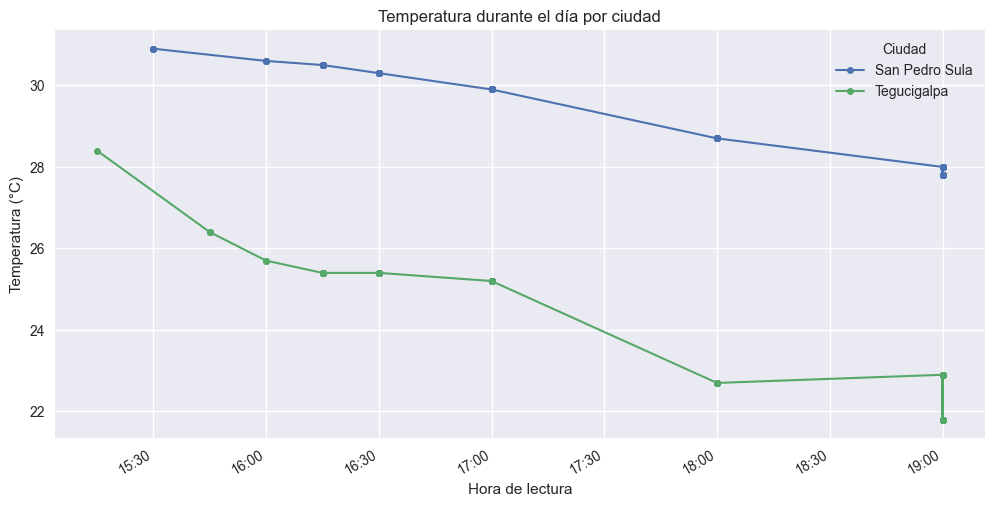

In [17]:
import matplotlib.dates as mdates

df_sorted['temperature'] = pd.to_numeric(df_sorted['temperature'], errors='coerce')

fig, ax = plt.subplots()

for city, group in df_sorted.groupby('city'):
    group = group.sort_values('read_at')

    ax.plot(
        group['read_at'],
        group['temperature'],
        marker='o',
        markersize=5,
        linewidth=1.5,
        label=city
    )

ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

ax.set_title('Temperatura durante el día por ciudad')
ax.set_xlabel('Hora de lectura')
ax.set_ylabel(f'Temperatura ({df_sorted["unit"].iloc[0]})')
ax.legend(title='Ciudad')

fig.autofmt_xdate()
plt.show()

## Comparación entre ciudades

Este gráfico resume la temperatura promedio por ciudad para comparar Tegucigalpa vs San Pedro Sula.

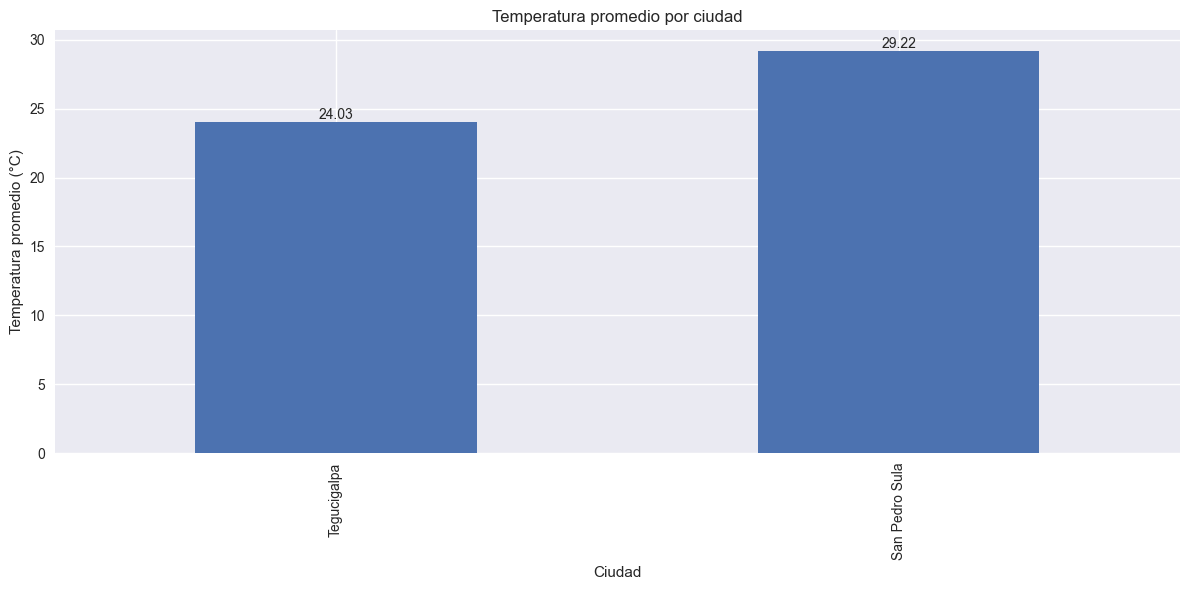

In [18]:
avg_sorted = summary['avg_temp'].sort_values()

ax = avg_sorted.plot(kind='bar')

ax.set_title('Temperatura promedio por ciudad')
ax.set_xlabel('Ciudad')
ax.set_ylabel(f'Temperatura promedio ({df_sorted["unit"].iloc[0]})')

for idx, value in enumerate(avg_sorted):
    ax.text(idx, value, f'{value:.2f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

## Explicación de lo aprendido

Se usa load balancer para poder distribuir las solicitudes entre instancias y poder aumentar la disponibilidad, en este caso, usamos 5 procesos recurrentes, lanzando 20 solicitudes cada segundo, generando 1,200 solicitudes por minuto. Con esa generación de solicitudes por minuto, se logra saturar de peticiones, generando que el API no nos devuelva data. 

Las tres APIs que se están usando es para balancear la carga, es decir, las tres APIs están simulando instancias, entonces, como estamos mandando muchas peticiones cada segundo, una API puede tender a caerse, entonces viene y se activa otra, y de esa forma logra balancear la carga y siempre poder mostrarnos la data.

Utilizamos la persistencia con MySQL, pues necesitamos tener la data guardado en algún lado, tanto para generar reportes como para disponer de la información cuando se requiera.

El proyecto se conecta con Big Data, ya que estamos generando tantas solicitudes por minuto, que estás se van a guardar a una base de datos, teniendo muchísima data para consultar, por ejemplo, se estuvo ejecutando el script para mandar peticiones al API cada seguindo, y se lograron guardar casi 20,000 registros, en un tiempo aproximado de 3 horas. Entonces, esa misma data nos puede servir para generar procesos ETL o mandarlos a un Data Lake, o bien, generar reportería.